# Maximum return/risk ratio with a jittered covariance

Maximize the return/risk ratio $\dfrac{\mu^\top w}{w^\top \Sigma w}$ — i.e. the **max-Sharpe / tangency** portfolio (return over variance; same argmax as return over std). In the short window $\Sigma$ is singular, so we add **jitter** $\Sigma \to \Sigma + \lambda I$. That makes it positive-definite *and* acts as **L2 (ridge) regularization** on $w$ — $w^\top(\Sigma+\lambda I)w = w^\top\Sigma w + \lambda\lVert w\rVert^2$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from stonks import get_prices, to_returns

%matplotlib inline


## Parameters

`ALPHA` sets the jitter as $\lambda = \alpha \cdot \mathrm{mean}(\mathrm{diag}\,\Sigma)$ — relative to the average daily variance, so it scales with the data.


In [29]:
TOP_N = 500
MONTHS = 3
PERIOD = "2y"      # cached; slice the last MONTHS
INTERVAL = "1d"
ALPHA = 1e-5        # jitter lambda = ALPHA * mean(diag(Sigma))


## Fetch, slice, compute $\mu$ and $\Sigma$


In [30]:
prices = get_prices(top_n=TOP_N, period=PERIOD, interval=INTERVAL, field="close")
cut = pd.Timestamp(prices.columns[-1]) - pd.DateOffset(months=MONTHS)
returns = to_returns(prices.loc[:, prices.columns >= cut]).dropna()

X = returns.to_numpy(dtype=float)
tickers = list(returns.index)
N, T = X.shape
mu = X.mean(axis=1)
Xc = X - mu[:, None]
Sigma = (Xc @ Xc.T) / (T - 1)
mu_t = torch.tensor(mu, dtype=torch.float64)

print(f"N={N}, T={T}, rank(Sigma)={np.linalg.matrix_rank(Sigma)}, cond(Sigma)=%.1e" % np.linalg.cond(Sigma))


N=453, T=63, rank(Sigma)=62, cond(Sigma)=1.9e+20


## Jitter: make $\Sigma$ positive-definite

$\Sigma_\lambda = \Sigma + \lambda I$. Every eigenvalue is shifted up by $\lambda$, so the null space disappears and the matrix becomes PD / well-conditioned.


In [31]:
lam = ALPHA #* np.mean(np.diag(Sigma))
Sigma_jit = Sigma + lam * np.eye(N)
Sjit_t = torch.tensor(Sigma_jit, dtype=torch.float64)
ev = np.linalg.eigvalsh(Sigma_jit)
print(f"lambda = {lam:.2e}  (= {ALPHA:g} x mean(diag))")
print(f"min eigenvalue {ev[0]:.2e} (>0 => PD)   cond(Sigma_jit)={np.linalg.cond(Sigma_jit):.1e}")


lambda = 1.00e-05  (= 1e-05 x mean(diag))
min eigenvalue 1.00e-05 (>0 => PD)   cond(Sigma_jit)=1.6e+04


## Closed form: the tangency direction

The ratio is scale-invariant, so setting $\nabla=0$ gives the optimal **direction** $w \propto \Sigma_\lambda^{-1}\mu$. Normalizing $\sum w = 1$ (this allows shorts):


In [32]:
w_cf = np.linalg.solve(Sigma_jit, mu)
w_cf = w_cf / w_cf.sum()
sharpe_cf = (w_cf @ mu) * 252 / np.sqrt(w_cf @ Sigma @ w_cf * 252)   # Sharpe measured on the real Sigma
print(f"closed form: Sharpe={sharpe_cf:.1f}, #shorts={int((w_cf<0).sum())}, sum={w_cf.sum():.3f}")
print("(huge -> the inverse still amplifies near-null-space noise; allow it only as a contrast)")


closed form: Sharpe=6049.6, #shorts=207, sum=1.000
(huge -> the inverse still amplifies near-null-space noise; allow it only as a contrast)


## Long-only max-ratio (softmax)

$w=\mathrm{softmax}(z)$ keeps $w\ge0$, $\sum w=1$; we ascend $z$ to maximize the ratio $\dfrac{\mu^\top w}{w^\top \Sigma_\lambda w}$ (autograd). The constraint stops it from exploiting the null space the way the closed form does.


In [33]:
z = torch.zeros(N, dtype=torch.float64, requires_grad=True)
opt = torch.optim.Adam([z], lr=1e-2)
for _ in range(10000):
    opt.zero_grad()
    w = torch.softmax(z, dim=0)
    ratio = (mu_t @ w) / (w @ Sjit_t @ w)
    (-ratio).backward()
    opt.step()

w_long = torch.softmax(z, dim=0).detach().numpy()
sharpe_long = (w_long @ mu) * 252 / np.sqrt(w_long @ Sigma @ w_long * 252)
print(f"long-only max-ratio: Sharpe={sharpe_long:.2f}, holdings(>1e-3)={int((w_long>1e-3).sum())}")
pd.Series(w_long, index=tickers).sort_values(ascending=False).head(10).round(3)


long-only max-ratio: Sharpe=19.96, holdings(>1e-3)=50


SYY     0.062
EOG     0.059
COP     0.056
HUBB    0.049
ALL     0.045
KO      0.045
TRV     0.043
BNY     0.042
AFL     0.036
BKNG    0.036
dtype: float64

Text(0.5, 1.0, 'Long-only max-ratio weights ($\\lambda$=1.0e-05, ridge)')

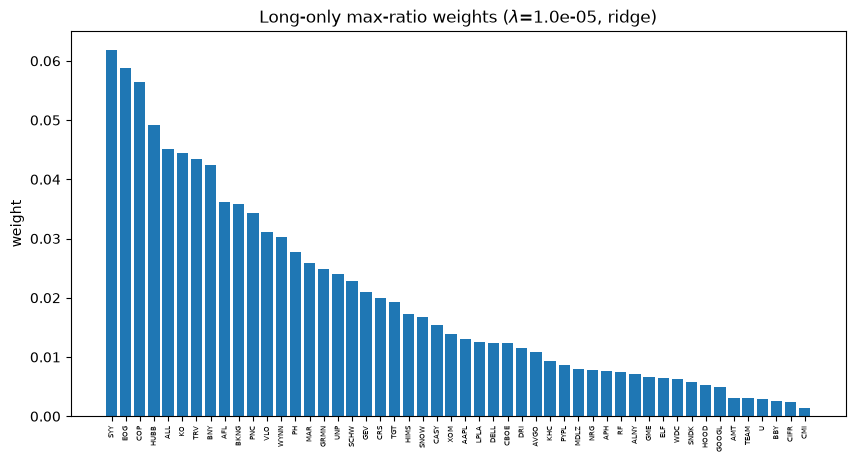

In [34]:
weights = pd.Series(w_long, index=tickers).sort_values(ascending=False)
nz = weights[weights > 1e-3]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(nz)), nz.values)
ax.set_xticks(range(len(nz))); ax.set_xticklabels(nz.index, rotation=90, fontsize=5)
ax.set_ylabel("weight"); ax.set_title(rf"Long-only max-ratio weights ($\lambda$={lam:.1e}, ridge)")


## Jitter sweep — the regularization tradeoff

Bigger $\lambda$ = stronger ridge: better conditioning, more diversification, lower (more honest) in-sample Sharpe. Smaller $\lambda$ = closer to the raw (singular) problem, more overfit.


In [26]:
print(f"{'alpha':>6} {'lambda':>10} {'cond':>10} {'long_Sharpe':>12} {'holdings':>9}")
for a in [0.01, 0.1, 1.0, 10.0]:
    l = a * np.mean(np.diag(Sigma))
    Sj = torch.tensor(Sigma + l*np.eye(N), dtype=torch.float64)
    z = torch.zeros(N, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.Adam([z], lr=0.05)
    for _ in range(10000):
        opt.zero_grad(); w = torch.softmax(z, 0)
        (-(mu_t @ w) / (w @ Sj @ w)).backward(); opt.step()
    w = torch.softmax(z, 0).detach().numpy()
    sh = (w @ mu) * 252 / np.sqrt(w @ Sigma @ w * 252)
    print(f"{a:6g} {l:10.2e} {np.linalg.cond(Sigma + l*np.eye(N)):10.1e} {sh:12.2f} {int((w>1e-3).sum()):9d}")


 alpha     lambda       cond  long_Sharpe  holdings
  0.01   1.16e-05    1.4e+04        19.97        51
   0.1   1.16e-04    1.4e+03        19.17        82
     1   1.16e-03    1.4e+02        15.15       168
    10   1.16e-02    1.5e+01        10.06       287
